Original max intensity (L_max): 229376.0

Processing with gamma:  0.1

E min = 0.000000, E max = 0.145975, E mean = 0.000629

K min = 1.21, K max = 9.64, K mean = 4.51
End at iteration 1 with MAE = 0.023117
f_c (rightmost trough) = 0.9941
Original max intensity (L_max): 229376.0

Processing with gamma:  0.2

E min = 0.000000, E max = 0.145975, E mean = 0.000629

K min = 1.47, K max = 92.93, K mean = 32.15
End at iteration 1 with MAE = 0.023060
f_c (rightmost trough) = 0.9941
Original max intensity (L_max): 229376.0

Processing with gamma:  0.3

E min = 0.000000, E max = 0.145975, E mean = 0.000629

K min = 1.78, K max = 895.88, K mean = 284.76
End at iteration 1 with MAE = 0.022945
f_c (rightmost trough) = 0.9941
Original max intensity (L_max): 229376.0

Processing with gamma:  0.4

E min = 0.000000, E max = 0.145975, E mean = 0.000629

K min = 2.16, K max = 8636.35, K mean = 2688.93
End at iteration 1 with MAE = 0.022697
f_c (rightmost trough) = 0.9941


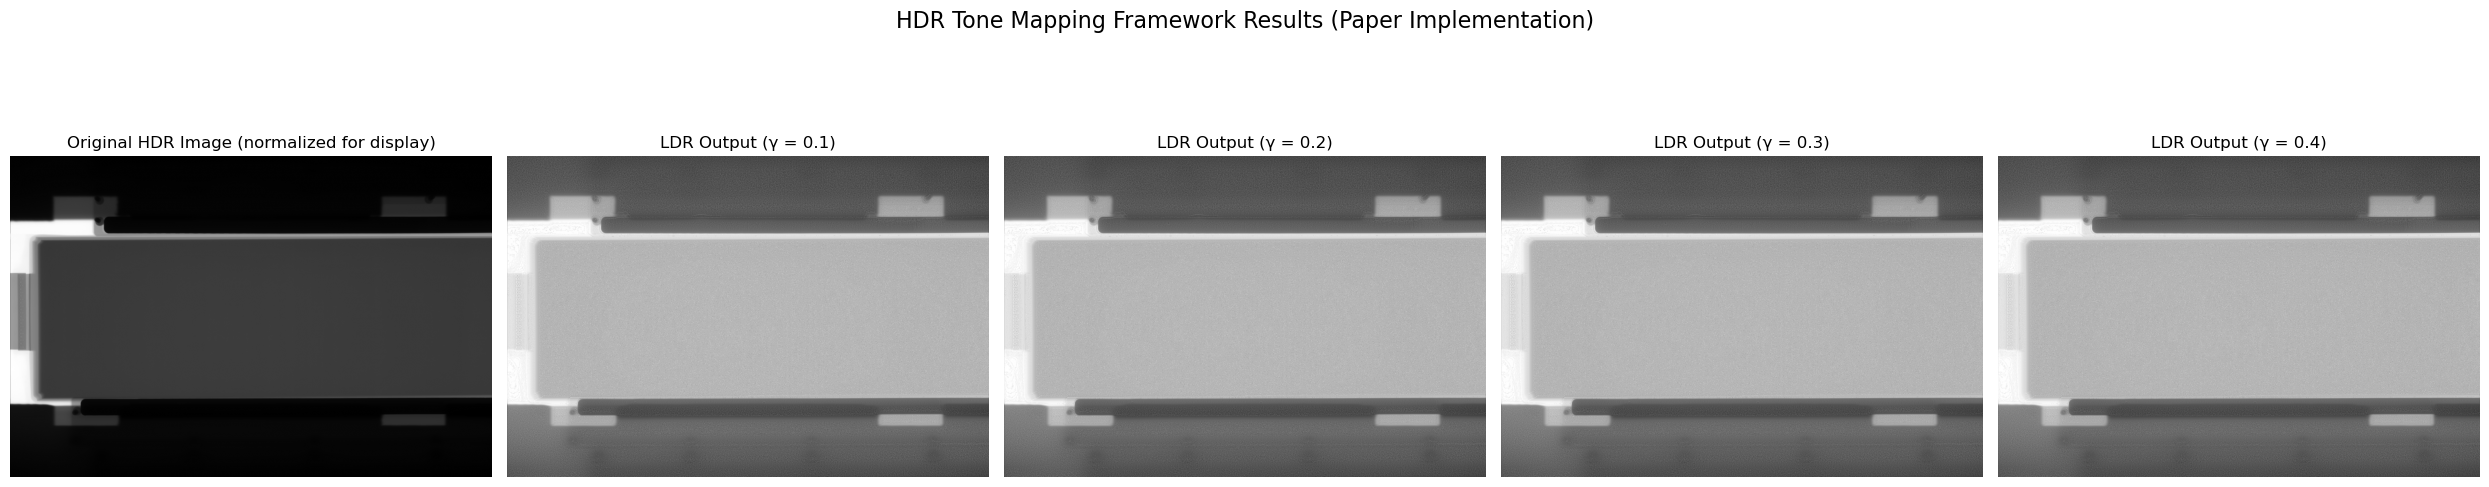


All results plotted successfully in Jupyter Notebook.


In [1]:
import sys
import os
root_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.generals.utils import load_hdr, save_ldr

from src.generals.utils import load_hdr, save_ldr
from src.gradient_tone_mapping.tonemap import tonemap
import matplotlib.pyplot as plt
import numpy as np
import cv2
from typing import List, Any
from src.gradient_tone_mapping.parameters import Parameters 
from src.generals.preprocess import preprocess
from src.generals.postprocess import postprocess


params = Parameters()

def run(input_path: str, output_path: str = None, gamma_values: List[float]=params.gamma_values):
    hdr = load_hdr(input_path)
    #preprocess here. But, because we do logarithm normalization, I think we don't need gamma correction as pre-processing.
    #hdr = preprocess(hdr, gamma=1.0)

    # =============================================
    # Prepare for plotting (just for exp)
    # =============================================
    fig, axs = plt.subplots(1, len(gamma_values) + 1, figsize=(5 * (len(gamma_values) + 1), 6))
    fig.suptitle("HDR Tone Mapping Framework Results (Paper Implementation)", fontsize=16)

    # Plot original input (normalized for display)
    I_display = np.clip(hdr) if hdr.max() > 0 else hdr
    axs[0].imshow(I_display, cmap='gray')
    axs[0].set_title("Original HDR Image (normalized for display)")
    axs[0].axis('off')
    

    # =============================================
    # Loop over each gamma value
    # =============================================
    for idx, gamma in enumerate(gamma_values):
        f_out = tonemap(hdr, gamma=gamma) # f_out ~ ldr
        #f_out = postprocess(f_out, gamma=1.0)

        # =============================================
        # Plot the LDR output (just for exp)
        # =============================================
        ldr_display = (f_out * 255.0).clip(0, 255).astype(np.uint8)
        axs[idx + 1].imshow(ldr_display, cmap='gray')
        axs[idx + 1].set_title(f"LDR Output (γ = {gamma})")
        axs[idx + 1].axis('off')

    plt.tight_layout()
    plt.show()
    print("\nAll results plotted successfully in Jupyter Notebook.")

# ====================== USAGE (in Jupyter Notebook) ======================
# Just run the cell below:
run("../../data/image_sample/1_Halo_Corner_Bottom/01_3072 x 2048_pos(1)_NG.hdr")
# "input.hdr" is the "poor_battery_images_dataset.zip/5_Corner_Cathode_5/02_3072 x 3072_pos(2)_NG.hdr" file, but i renamed it to "input.hdr" for simplicity.
# you can test with any file, just update the image path and run ..